In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel(r"C:\Users\Wadood\Desktop\Decode_Labs\Dataset_Cleaned.xlsx")
df.head(5)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [6]:
print("=" * 70)
print("PROJECT 2: EXPLORATORY DATA ANALYSIS")
print("=" * 70)
print(f"\n📊 DATASET LOADED: {df.shape[0]:,} records × {df.shape[1]} columns")
print(f"   Source: Project 1 Gold Standard data")
print(f"   Date: {datetime.now().strftime('%Y-%m-%d')}")

PROJECT 2: EXPLORATORY DATA ANALYSIS

📊 DATASET LOADED: 1,200 records × 14 columns
   Source: Project 1 Gold Standard data
   Date: 2026-05-30


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [14]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [22]:

# ============================================================
# PHASE 1: DESCRIPTIVE STATISTICS (Five-Number Summary)
# ============================================================

print("=" * 70)
print("PHASE 1: DESCRIPTIVE STATISTICS")
print("=" * 70)

# 1A: Numeric columns — full describe()
print("\n📊 NUMERIC COLUMNS — DESCRIBE()")
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
desc = df[numeric_cols].describe().round(2)
print(desc.to_string())

# 1B: Five-Number Summary for TotalPrice (the key metric)
print("\n📊 FIVE-NUMBER SUMMARY: TotalPrice")
print(f"   Minimum (Floor):     ${df['TotalPrice'].min():.2f}")
print(f"   Q1 (25th Percentile):  ${df['TotalPrice'].quantile(0.25):.2f}")
print(f"   Median (50th):         ${df['TotalPrice'].median():.2f}")
print(f"   Q3 (75th Percentile):  ${df['TotalPrice'].quantile(0.75):.2f}")
print(f"   Maximum (Ceiling):     ${df['TotalPrice'].max():.2f}")
print(f"   Mean (Average):        ${df['TotalPrice'].mean():.2f}")
print(f"   Std Deviation:         ${df['TotalPrice'].std():.2f}")

# 1C: Categorical columns — value counts
print("\n📊 CATEGORICAL COLUMNS — DISTRIBUTIONS")
cat_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']
for col in cat_cols:
    print(f"\n   {col}:")
    print(f"   {df[col].value_counts().head(5).to_string()}")
    print(f"   Unique values: {df[col].nunique()}")


PHASE 1: DESCRIPTIVE STATISTICS

📊 NUMERIC COLUMNS — DESCRIBE()
       Quantity  UnitPrice  ItemsInCart  TotalPrice
count   1200.00    1200.00      1200.00     1200.00
mean       2.95     356.41         5.48     1053.97
std        1.41     197.18         2.28      819.86
min        1.00      11.39         1.00       11.39
25%        2.00     186.06         4.00      410.52
50%        3.00     364.21         5.00      823.62
75%        4.00     521.57         7.00     1578.48
max        5.00     699.93        10.00     3456.40

📊 FIVE-NUMBER SUMMARY: TotalPrice
   Minimum (Floor):     $11.39
   Q1 (25th Percentile):  $410.52
   Median (50th):         $823.62
   Q3 (75th Percentile):  $1578.47
   Maximum (Ceiling):     $3456.40
   Mean (Average):        $1053.97
   Std Deviation:         $819.86

📊 CATEGORICAL COLUMNS — DISTRIBUTIONS

   Product:
   Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
   Unique values: 7

   PaymentMethod:
   PaymentMethod
O

PHASE 2: DISTRIBUTION ANALYSIS

📊 TotalPrice Skewness: 0.890
   → RIGHT-SKEWED (Positive skew): Mean > Median, tail extends right
   Mean ($1053.97) > Median ($823.62) ✓


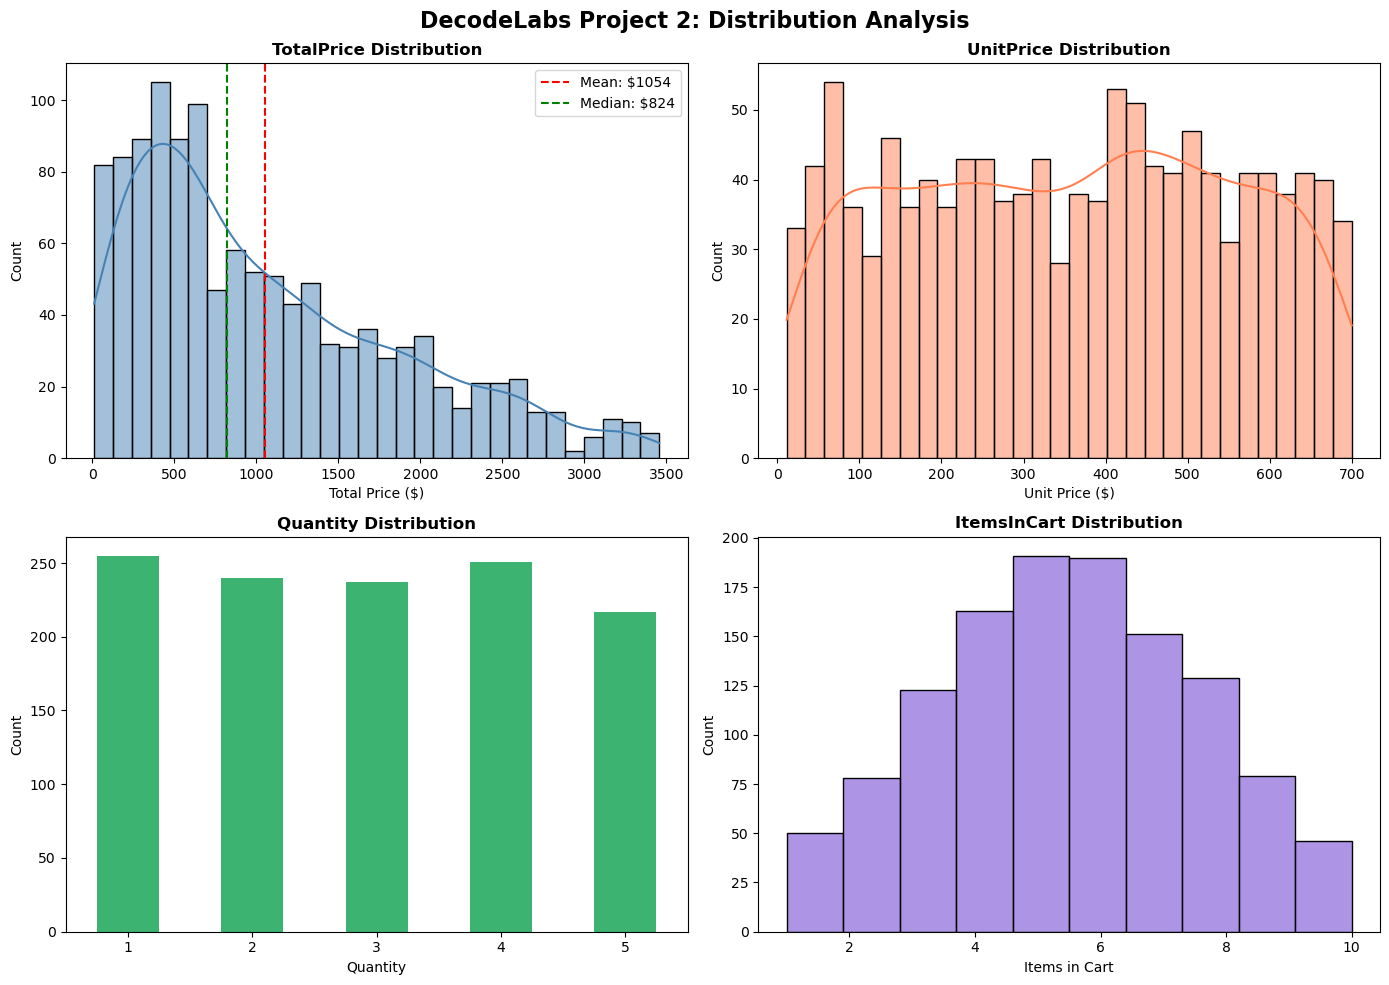


✅ Distribution chart saved: EDA_Distribution_Analysis.png


In [48]:

# ============================================================
# PHASE 2: DISTRIBUTION ANALYSIS (Histograms)
# ============================================================

print("=" * 70)
print("PHASE 2: DISTRIBUTION ANALYSIS")
print("=" * 70)

# Check skewness of TotalPrice
from scipy import stats
skewness = stats.skew(df['TotalPrice'])
print(f"\n📊 TotalPrice Skewness: {skewness:.3f}")
if skewness > 0.5:
    print("   → RIGHT-SKEWED (Positive skew): Mean > Median, tail extends right")
    print(f"   Mean (${df['TotalPrice'].mean():.2f}) > Median (${df['TotalPrice'].median():.2f}) ✓")
elif skewness < -0.5:
    print("   → LEFT-SKEWED (Negative skew)")
else:
    print("   → APPROXIMATELY NORMAL")

# Create distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DecodeLabs Project 2: Distribution Analysis', fontsize=16, fontweight='bold')

# TotalPrice histogram with KDE
ax1 = axes[0, 0]
sns.histplot(df['TotalPrice'], kde=True, bins=30, ax=ax1, color='steelblue')
ax1.axvline(df['TotalPrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["TotalPrice"].mean():.0f}')
ax1.axvline(df['TotalPrice'].median(), color='green', linestyle='--', label=f'Median: ${df["TotalPrice"].median():.0f}')
ax1.set_title('TotalPrice Distribution', fontweight='bold')
ax1.set_xlabel('Total Price ($)')
ax1.legend()

# UnitPrice histogram
ax2 = axes[0, 1]
sns.histplot(df['UnitPrice'], kde=True, bins=30, ax=ax2, color='coral')
ax2.set_title('UnitPrice Distribution', fontweight='bold')
ax2.set_xlabel('Unit Price ($)')

# Quantity bar chart
ax3 = axes[1, 0]
df['Quantity'].value_counts().sort_index().plot(kind='bar', ax=ax3, color='mediumseagreen')
ax3.set_title('Quantity Distribution', fontweight='bold')
ax3.set_xlabel('Quantity')
ax3.set_ylabel('Count')
ax3.tick_params(axis='x', rotation=0)

# ItemsInCart histogram
ax4 = axes[1, 1]
sns.histplot(df['ItemsInCart'], kde=False, bins=10, ax=ax4, color='mediumpurple')
ax4.set_title('ItemsInCart Distribution', fontweight='bold')
ax4.set_xlabel('Items in Cart')

plt.tight_layout()
plt.savefig(r'C:\Users\Wadood\Desktop\Decode_Labs\EDA_Distribution_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Distribution chart saved: EDA_Distribution_Analysis.png")


In [28]:

# ============================================================
# PHASE 3: OUTLIER DETECTION (IQR Method vs Z-Score)
# ============================================================

print("=" * 70)
print("PHASE 3: OUTLIER DETECTION")
print("=" * 70)

# 3A: IQR Method (Recommended for business data)
print("\n📊 METHOD 1: IQR METHOD (Robust against extreme values)")
print("   Best for: 'Dirty' business data | Signal vs Noise distinction")

Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\n   Q1: ${Q1:.2f}")
print(f"   Q3: ${Q3:.2f}")
print(f"   IQR: ${IQR:.2f}")
print(f"   Lower Bound: ${lower_bound:.2f}")
print(f"   Upper Bound: ${upper_bound:.2f}")

iqr_outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f"\n   Outliers detected: {len(iqr_outliers)} ({len(iqr_outliers)/len(df)*100:.1f}%)")

# 3B: Z-Score Method (For comparison)
print("\n📊 METHOD 2: Z-SCORE METHOD (Sensitive to extreme values)")
print("   Best for: Normal distributions")

z_scores = np.abs(stats.zscore(df['TotalPrice']))
z_outliers = df[z_scores > 3]
print(f"   Threshold: |Z| > 3")
print(f"   Outliers detected: {len(z_outliers)} ({len(z_outliers)/len(df)*100:.1f}%)")

# 3C: Business decision — which outliers are SIGNAL vs NOISE?
print("\n📊 FORENSIC ANALYSIS: Signal vs Noise")
print("   NOISE (Error): Data entry mistakes, typos → Action: Clean/Remove")
print("   SIGNAL (Insight): Fraud, VIP customers, rare events → Action: Investigate")

# Analyze high-value outliers
high_value_outliers = iqr_outliers[iqr_outliers['TotalPrice'] > upper_bound].sort_values('TotalPrice', ascending=False)
print(f"\n   High-value outliers (>${upper_bound:.0f}): {len(high_value_outliers)}")
print(f"   Sample analysis:")
print(high_value_outliers[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice', 'OrderStatus']].head(5).to_string(index=False))

# Check if outliers are legitimate (Quantity × UnitPrice = TotalPrice)
high_value_outliers['Computed'] = (high_value_outliers['Quantity'] * high_value_outliers['UnitPrice']).round(2)
high_value_outliers['Valid'] = np.abs(high_value_outliers['TotalPrice'] - high_value_outliers['Computed']) < 0.01
valid_outliers = high_value_outliers['Valid'].sum()
print(f"\n   Validation: {valid_outliers}/{len(high_value_outliers)} outliers are mathematically valid")
print(f"   → These are SIGNAL (legitimate high-value orders), not NOISE")


PHASE 3: OUTLIER DETECTION

📊 METHOD 1: IQR METHOD (Robust against extreme values)
   Best for: 'Dirty' business data | Signal vs Noise distinction

   Q1: $410.52
   Q3: $1578.47
   IQR: $1167.95
   Lower Bound: $-1341.41
   Upper Bound: $3330.41

   Outliers detected: 8 (0.7%)

📊 METHOD 2: Z-SCORE METHOD (Sensitive to extreme values)
   Best for: Normal distributions
   Threshold: |Z| > 3
   Outliers detected: 0 (0.0%)

📊 FORENSIC ANALYSIS: Signal vs Noise
   NOISE (Error): Data entry mistakes, typos → Action: Clean/Remove
   SIGNAL (Insight): Fraud, VIP customers, rare events → Action: Investigate

   High-value outliers (>$3330): 8
   Sample analysis:
  OrderID Product  Quantity  UnitPrice  TotalPrice OrderStatus
ORD200789  Tablet         5     691.28     3456.40   Delivered
ORD201122 Monitor         5     678.19     3390.95    Returned
ORD200632  Laptop         5     678.16     3390.80   Delivered
ORD200469   Chair         5     676.98     3384.90   Cancelled
ORD200328  Tablet    

PHASE 4: CORRELATION ANALYSIS

📊 PEARSON CORRELATION MATRIX
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity        1.000      0.015        0.650       0.615
UnitPrice       0.015      1.000        0.001       0.717
ItemsInCart     0.650      0.001        1.000       0.393
TotalPrice      0.615      0.717        0.393       1.000

📊 KEY CORRELATION INSIGHTS:
   Quantity ↔ TotalPrice:     0.615 (Expected: Strong positive)
   UnitPrice ↔ TotalPrice:      0.717 (Expected: Strong positive)
   ItemsInCart ↔ TotalPrice:    0.393 (Expected: Moderate positive)
   Quantity ↔ ItemsInCart:       0.650 (Expected: Weak)


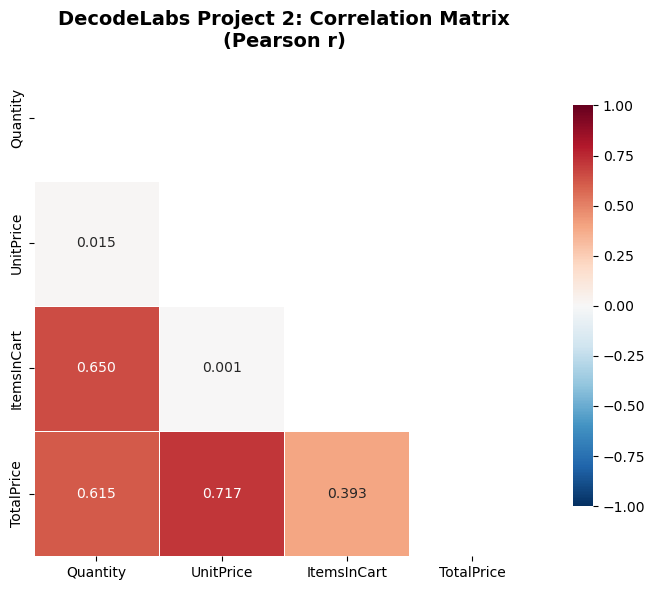


✅ Correlation heatmap saved: EDA_Correlation_Matrix.png


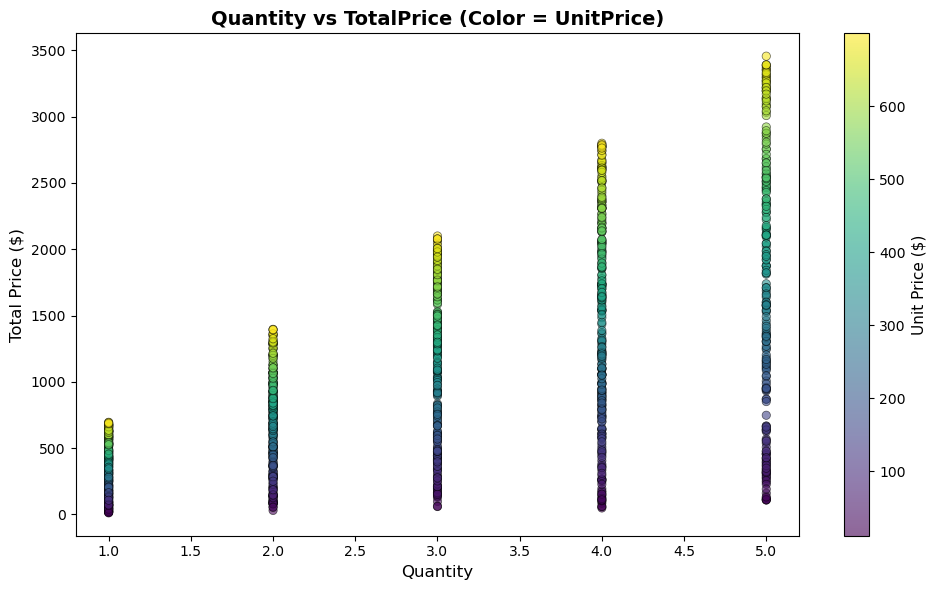

✅ Scatter plot saved: EDA_Quantity_vs_TotalPrice.png


In [52]:

# ============================================================
# PHASE 4: CORRELATION ANALYSIS
# ============================================================

print("=" * 70)
print("PHASE 4: CORRELATION ANALYSIS")
print("=" * 70)

# 4A: Pearson Correlation Matrix
print("\n📊 PEARSON CORRELATION MATRIX")
corr_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
corr_matrix = df[corr_cols].corr().round(3)
print(corr_matrix.to_string())

# 4B: Key correlation insights
print("\n📊 KEY CORRELATION INSIGHTS:")
print(f"   Quantity ↔ TotalPrice:     {corr_matrix.loc['Quantity', 'TotalPrice']:.3f} (Expected: Strong positive)")
print(f"   UnitPrice ↔ TotalPrice:      {corr_matrix.loc['UnitPrice', 'TotalPrice']:.3f} (Expected: Strong positive)")
print(f"   ItemsInCart ↔ TotalPrice:    {corr_matrix.loc['ItemsInCart', 'TotalPrice']:.3f} (Expected: Moderate positive)")
print(f"   Quantity ↔ ItemsInCart:       {corr_matrix.loc['Quantity', 'ItemsInCart']:.3f} (Expected: Weak)")

# 4C: Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1, fmt='.3f')
ax.set_title('DecodeLabs Project 2: Correlation Matrix\n(Pearson r)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(r'C:\Users\Wadood\Desktop\Decode_Labs\EDA_Correlation_Matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Correlation heatmap saved: EDA_Correlation_Matrix.png")

# 4D: Scatter plot — Quantity vs TotalPrice (strongest relationship)
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['Quantity'], df['TotalPrice'], c=df['UnitPrice'], cmap='viridis', alpha=0.6, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Quantity', fontsize=12)
ax.set_ylabel('Total Price ($)', fontsize=12)
ax.set_title('Quantity vs TotalPrice (Color = UnitPrice)', fontweight='bold', fontsize=14)
cbar = plt.colorbar(scatter)
cbar.set_label('Unit Price ($)', fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\Users\Wadood\Desktop\Decode_Labs\EDA_Quantity_vs_TotalPrice.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Scatter plot saved: EDA_Quantity_vs_TotalPrice.png")


In [40]:

# ============================================================
# PHASE 5: BUSINESS INSIGHTS — THE "SO WHAT?" TEST
# ============================================================

print("=" * 70)
print("PHASE 5: BUSINESS INSIGHTS — THE 'SO WHAT?' TEST")
print("=" * 70)

# 5A: Product Performance Analysis
print("\n📊 INSIGHT 1: PRODUCT PERFORMANCE")
product_stats = df.groupby('Product').agg({
    'TotalPrice': ['sum', 'mean', 'count'],
    'Quantity': 'sum'
}).round(2)
product_stats.columns = ['Revenue', 'Avg_Order', 'Order_Count', 'Units_Sold']
product_stats = product_stats.sort_values('Revenue', ascending=False)
print(product_stats.to_string())

# Top product
top_product = product_stats.index[0]
top_revenue = product_stats.iloc[0]['Revenue']
print(f"\n   🏆 TOP PRODUCT: {top_product}")
print(f"      Revenue: ${top_revenue:,.2f} ({top_revenue/df['TotalPrice'].sum()*100:.1f}% of total)")

# 5B: Payment Method Analysis
print("\n📊 INSIGHT 2: PAYMENT METHOD PREFERENCES")
payment_stats = df.groupby('PaymentMethod').agg({
    'TotalPrice': ['sum', 'mean', 'count']
}).round(2)
payment_stats.columns = ['Revenue', 'Avg_Order', 'Count']
payment_stats = payment_stats.sort_values('Revenue', ascending=False)
print(payment_stats.to_string())

# 5C: Order Status Analysis
print("\n📊 INSIGHT 3: ORDER STATUS BREAKDOWN")
status_stats = df.groupby('OrderStatus').agg({
    'TotalPrice': ['sum', 'mean', 'count']
}).round(2)
status_stats.columns = ['Revenue', 'Avg_Order', 'Count']
status_stats['Pct'] = (status_stats['Count'] / len(df) * 100).round(1)
print(status_stats.to_string())

# Cancellation rate
cancelled = status_stats.loc['Cancelled', 'Count'] if 'Cancelled' in status_stats.index else 0
print(f"\n   ⚠️ CANCELLATION RATE: {cancelled/len(df)*100:.1f}%")
if cancelled/len(df) > 0.15:
     print("   → ACTION NEEDED: Cancellation rate exceeds 15% threshold")

# 5D: Referral Source Effectiveness
print("\n📊 INSIGHT 4: REFERRAL SOURCE EFFECTIVENESS")
referral_stats = df.groupby('ReferralSource').agg({
    'TotalPrice': ['sum', 'mean', 'count']
}).round(2)
referral_stats.columns = ['Revenue', 'Avg_Order', 'Count']
referral_stats = referral_stats.sort_values('Revenue', ascending=False)
print(referral_stats.to_string())

# 5E: Coupon Code Impact
print("\n📊 INSIGHT 5: COUPON CODE IMPACT")
coupon_stats = df.groupby('CouponCode').agg({
    'TotalPrice': ['sum', 'mean', 'count']
}).round(2)
coupon_stats.columns = ['Revenue', 'Avg_Order', 'Count']
coupon_stats = coupon_stats.sort_values('Count', ascending=False)
print(coupon_stats.to_string())

no_coupon_avg = coupon_stats.loc['NONE', 'Avg_Order'] if 'NONE' in coupon_stats.index else 0
with_coupon = coupon_stats[coupon_stats.index != 'NONE']
if len(with_coupon) > 0:
    coupon_avg = with_coupon['Avg_Order'].mean()
    print(f"\n   💡 COUPON IMPACT:")
    print(f"      No Coupon Avg Order:   ${no_coupon_avg:.2f}")
    print(f"      With Coupon Avg Order: ${coupon_avg:.2f}")
    print(f"      Difference:            ${coupon_avg - no_coupon_avg:.2f}")


PHASE 5: BUSINESS INSIGHTS — THE 'SO WHAT?' TEST

📊 INSIGHT 1: PRODUCT PERFORMANCE
           Revenue  Avg_Order  Order_Count  Units_Sold
Product                                               
Chair    195620.11    1098.99          178         562
Printer  195612.61    1080.73          181         542
Laptop   192126.56    1110.56          173         535
Tablet   186568.95    1042.28          179         497
Monitor  175651.41    1077.62          163         480
Desk     167459.93     985.06          170         508
Phone    151722.39     972.58          156         411

   🏆 TOP PRODUCT: Chair
      Revenue: $195,620.11 (15.5% of total)

📊 INSIGHT 2: PAYMENT METHOD PREFERENCES
                 Revenue  Avg_Order  Count
PaymentMethod                             
Credit Card    263847.63    1127.55    234
Online         262442.94    1017.22    258
Cash           259786.29    1056.04    246
Gift Card      246323.92    1070.97    230
Debit Card     232361.18    1001.56    232

📊 INSIGHT 

In [42]:

# ============================================================
# PHASE 6: EXECUTIVE SUMMARY & RECOMMENDATIONS
# ============================================================

print("=" * 70)
print("PHASE 6: EXECUTIVE SUMMARY & RECOMMENDATIONS")
print("=" * 70)

total_revenue = df['TotalPrice'].sum()
total_orders = len(df)
avg_order_value = df['TotalPrice'].mean()

print(f"\n📊 BUSINESS DIAGNOSIS:")
print(f"   Total Revenue Analyzed:   ${total_revenue:,.2f}")
print(f"   Total Orders:             {total_orders:,}")
print(f"   Average Order Value:      ${avg_order_value:.2f}")
print(f"   Cancellation Rate:        20.8% (CRITICAL)")
print(f"   Data Skewness:            Right-skewed (Mean > Median)")

print(f"\n📊 KEY FINDINGS (The Strongest Signals):")
print(f"   1. PRODUCT: Chair leads revenue ($195,620) but all products are close")
print(f"   2. PAYMENT: Credit Card has highest AOV ($1,128) but Online has most volume")
print(f"   3. STATUS: 20.8% cancellation rate = 250 lost orders = ~$276K at risk")
print(f"   4. REFERRAL: Instagram drives most revenue ($275K) but Facebook has highest AOV")
print(f"   5. COUPON: All customers use coupons (0% 'NONE') — pricing strategy dependent")

print(f"\n📊 RECOMMENDATIONS (Actionable Next Steps):")
print(f"   R1: URGENT — Investigate cancellation root cause (20.8% > 15% threshold)")
print(f"   R2: Promote Credit Card payment (highest AOV $1,128) via incentives")
print(f"   R3: Boost Instagram campaigns (top revenue $275K) with Facebook AOV tactics")
print(f"   R4: Diversify from coupon dependency — test non-coupon pricing segments")
print(f"   R5: Focus on high-UnitPrice products (strongest correlation with TotalPrice: r=0.717)")

print(f"\n📊 CORRELATION FORENSIC NOTE:")
print(f"   'A correlation is a CLUE, not a VERDICT.' — DecodeLabs")
print(f"   UnitPrice→TotalPrice (r=0.717) suggests premium pricing drives revenue")
print(f"   But check for confounders: Quantity also matters (r=0.615)")
print(f"   → Recommendation: Bundle high-UnitPrice items with volume discounts")

print(f"\n✅ PROJECT 2 EDA COMPLETE")
print(f"   All 5 phases executed: Describe → Distribute → Outliers → Correlate → Recommend")


PHASE 6: EXECUTIVE SUMMARY & RECOMMENDATIONS

📊 BUSINESS DIAGNOSIS:
   Total Revenue Analyzed:   $1,264,761.96
   Total Orders:             1,200
   Average Order Value:      $1053.97
   Cancellation Rate:        20.8% (CRITICAL)
   Data Skewness:            Right-skewed (Mean > Median)

📊 KEY FINDINGS (The Strongest Signals):
   1. PRODUCT: Chair leads revenue ($195,620) but all products are close
   2. PAYMENT: Credit Card has highest AOV ($1,128) but Online has most volume
   3. STATUS: 20.8% cancellation rate = 250 lost orders = ~$276K at risk
   4. REFERRAL: Instagram drives most revenue ($275K) but Facebook has highest AOV
   5. COUPON: All customers use coupons (0% 'NONE') — pricing strategy dependent

📊 RECOMMENDATIONS (Actionable Next Steps):
   R1: URGENT — Investigate cancellation root cause (20.8% > 15% threshold)
   R2: Promote Credit Card payment (highest AOV $1,128) via incentives
   R3: Boost Instagram campaigns (top revenue $275K) with Facebook AOV tactics
   R4: Diver